## Import libraries

In [ ]:
!pip install -q open_clip_torch
!python -m spacy download en_core_web_sm

In [ ]:
import torch
import numpy as np
import pandas as pd
import open_clip
import spacy
import string
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from datasets import load_dataset
from sklearn.linear_model import Ridge
from PIL import Image
from transformers import AutoTokenizer
import seaborn as sns
import matplotlib.patches as patches
from scipy.stats import spearmanr
from sklearn.metrics import auc, r2_score
import os
import json
from torch.utils.data import Dataset
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

## Load model

BiomedClip

In [ ]:
MODEL_ID = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(
    MODEL_ID, device=device
)
model.eval()
tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224")

## Load dataset

ROCOv2

In [ ]:
dataset = load_dataset("eltorio/ROCOv2-radiology", split="train", streaming=True)
sample = next(iter(dataset))
image_orig = sample["image"].convert("RGB")
caption_orig = sample["caption"]

plt.imshow(image_orig)
plt.title(f"Caption: {caption_orig}")
plt.axis("off")
plt.show()

image_tensor = preprocess_val(image_orig).unsqueeze(0).to(device)

Exploring dataset and extracting images with short and long captions

In [ ]:
dataset_roco_subset = list(dataset.take(500))

In [ ]:
captions = []
original_samples = []
for i, sample in tqdm(enumerate(dataset_roco_subset)):
    captions.append(sample["caption"])
    original_samples.append(sample)

lengths = [len(c.split()) for c in captions]

p20 = np.percentile(lengths, 20)
p80 = np.percentile(lengths, 80)

print(f"20th percentile: {p20:.2f} words")
print(f"80th percentile: {p80:.2f} words")

plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(p20, color='red', linestyle='dashed', linewidth=2, label=f'20th percentile ({p20:.1f})')
plt.axvline(p80, color='green', linestyle='dashed', linewidth=2, label=f'80th percentile ({p80:.1f})')

plt.title("Caption Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Number of Samples")
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

short_indices = [i for i, length in enumerate(lengths) if length < p20]
long_indices = [i for i, length in enumerate(lengths) if length > p80]

short_samples = [original_samples[i] for i in short_indices]
long_samples = [original_samples[i] for i in long_indices]

print(f"Number of samples in short set (< {p20:.1f} words): {len(short_samples)}")
print(f"Number of samples in long set (> {p80:.1f} words): {len(long_samples)}")

In [ ]:
random_ids = np.random.choice(len(short_samples), size=10, replace=False)
short_samples_subset = [short_samples[i] for i in random_ids]
long_samples_subset = [long_samples[i] for i in random_ids]

In [ ]:
for i in range(len(short_samples_subset)):
    sample = short_samples_subset[i]
    show_sample(sample)

In [ ]:
for i in range(len(long_samples_subset)):
    sample = long_samples_subset[i]
    show_sample(sample)

Function to show sample

In [ ]:
def show_sample(sample):
    image = sample["image"].convert("RGB")
    caption = sample["caption"]
    plt.imshow(image)
    plt.title(f"Caption: {caption}")
    plt.axis("off")
    plt.show()

In [ ]:
sample=dataset_roco_subset[0]

In [ ]:
show_sample(sample)

## Tree parsing - grouping tokens strategies

In [ ]:
nlp = spacy.load("en_core_web_sm")

class TextParser:
    def __init__(self, tokenizer, nlp_model):
        self.tokenizer = tokenizer
        self.nlp = nlp_model

    def get_token_mapping(self, text):
        """
        Returns valid_map and input_ids.
        valid_map: list of tuples (idx, start_char, end_char)
        input_ids: list of tokenizer token IDs
        """
        enc = self.tokenizer(text, return_offsets_mapping=True, add_special_tokens=True)
        offsets = enc['offset_mapping']
        input_ids = enc['input_ids']
        special_ids = set(self.tokenizer.all_special_ids)

        valid_map = []
        for idx, (start, end) in enumerate(offsets):
            if input_ids[idx] in special_ids or start == end:
                continue
            valid_map.append((idx, start, end))
        return valid_map, input_ids

    def map_spans_to_model(self, spans, valid_map):
        """
        spans: list of spacy span objects
        valid_map: list of tuples (idx, start_char, end_char)
        Returns list of players for differen strategies.
        """
        players = []
        covered_indices = set()

        for span in spans:
            token_indices = []
            span_start = span.start_char if hasattr(span, 'start_char') else span.idx
            span_end = span.end_char if hasattr(span, 'end_char') else (span.idx + len(span))

            for t_idx, start, end in valid_map:
                if start >= span_start and end <= span_end:
                    token_indices.append(t_idx)
                elif (start < span_end and end > span_start):
                    overlap = min(end, span_end) - max(start, span_start)
                    if overlap > (end - start) * 0.5:
                        token_indices.append(t_idx)

            new_indices = [x for x in token_indices if x not in covered_indices]
            if new_indices:
                players.append({"name": span.text, "indices": new_indices})
                covered_indices.update(new_indices)
        return players

    def filter_players(self, players):
        """
        players: list of players
        Returns cleaned list of players from dots, ##, empty strings and punctuation
        """
        cleaned = []
        for p in players:
            name = p['name'].replace("##", "").strip()
            if not name: continue
            if all(char in string.punctuation for char in name): continue

            new_p = p.copy()
            new_p['name'] = name
            cleaned.append(new_p)
        return cleaned

    def group(self, text, strategy="smart_dep"):
        """
        Main function to group tokens and create players as grouped tokens
        Available strategies: 'raw', 'words', 'noun_chunks', 'smart_depth', 'nouns_only'
        """
        valid_map, input_ids = self.get_token_mapping(text)

        # players as raw tokens from tokenizer
        if strategy == "raw":
            players = []
            all_tokens = self.tokenizer.convert_ids_to_tokens(input_ids)
            for t_idx, start, end in valid_map:
                players.append({"name": all_tokens[t_idx], "indices": [t_idx]})

        # players as words hydrant is one player not hydr, ant as two players
        elif strategy == "words":
            doc = self.nlp(text)
            players = self.map_spans_to_model([t for t in doc], valid_map)

        # groups nouns with their phrases
        elif strategy == "noun_chunks":
            doc = self.nlp(text)
            spans = list(doc.noun_chunks)
            chunk_tokens = set([t.i for chunk in spans for t in chunk])
            for token in doc:
                if token.i not in chunk_tokens:
                    spans.append(token)
            spans.sort(key=lambda x: x.start_char if hasattr(x, 'start_char') else x.idx)
            players = self.map_spans_to_model(spans, valid_map)

        # combines negations, adjectives and verbs with commonon logic
        elif strategy == "smart_depth":
            doc = self.nlp(text)
            spans = []
            visited = set()
            modifiers = ['compound', 'amod', 'det', 'neg', 'nummod', 'aux', 'auxpass', 'prt', 'advmod']
            for token in doc:
                if token.i in visited: continue
                if token.dep_ in modifiers: continue
                group = [token]
                for child in token.children:
                    if child.dep_ in modifiers: group.append(child)
                group.sort(key=lambda t: t.i)
                spans.append(doc[group[0].i : group[-1].i + 1])
                visited.update([t.i for t in group])
            for token in doc:
                if token.i not in visited: spans.append(token)
            spans.sort(key=lambda x: x.start_char if hasattr(x, 'start_char') else x.idx)
            players = self.map_spans_to_model(spans, valid_map)
        elif strategy == "nouns_only":
            doc = self.nlp(text)
            spans = [token for token in doc if token.pos_ in ["NOUN", "PROPN"]]
            players = self.map_spans_to_model(spans, valid_map)

        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        return self.filter_players(players), input_ids

Example: Head CT demonstrating left parotiditis.

In [ ]:
text_parser = TextParser(tokenizer, nlp)
text_parser.group(caption_orig, strategy="raw")

([{'name': 'head', 'indices': [1]},
  {'name': 'ct', 'indices': [2]},
  {'name': 'demonstrating', 'indices': [3]},
  {'name': 'left', 'indices': [4]},
  {'name': 'parotid', 'indices': [5]},
  {'name': 'itis', 'indices': [6]}],
 [2, 3963, 3215, 8238, 3326, 15041, 2768, 17, 3])

In [ ]:
text_parser = TextParser(tokenizer, nlp)
text_parser.group(caption_orig, strategy="words")

([{'name': 'Head', 'indices': [1]},
  {'name': 'CT', 'indices': [2]},
  {'name': 'demonstrating', 'indices': [3]},
  {'name': 'left', 'indices': [4]},
  {'name': 'parotiditis', 'indices': [5, 6]}],
 [2, 3963, 3215, 8238, 3326, 15041, 2768, 17, 3])

In [ ]:
text_parser = TextParser(tokenizer, nlp)
text_parser.group(caption_orig, strategy="noun_chunks")

([{'name': 'Head CT', 'indices': [1, 2]},
  {'name': 'demonstrating', 'indices': [3]},
  {'name': 'left parotiditis', 'indices': [4, 5, 6]}],
 [2, 3963, 3215, 8238, 3326, 15041, 2768, 17, 3])

In [ ]:
text_parser = TextParser(tokenizer, nlp)
text_parser.group(caption_orig, strategy="smart_depth")

([{'name': 'Head CT', 'indices': [1, 2]},
  {'name': 'demonstrating', 'indices': [3]},
  {'name': 'left parotiditis', 'indices': [4, 5, 6]}],
 [2, 3963, 3215, 8238, 3326, 15041, 2768, 17, 3])

In [ ]:
text_parser = TextParser(tokenizer, nlp)
text_parser.group(caption_orig, strategy="nouns_only")

([{'name': 'Head', 'indices': [1]},
  {'name': 'CT', 'indices': [2]},
  {'name': 'parotiditis', 'indices': [5, 6]}],
 [2, 3963, 3215, 8238, 3326, 15041, 2768, 17, 3])

Example: Viral pneumonia is not ruled out.

In [ ]:
auxiliary_text="Viral pneumonia is not ruled out."

In [ ]:
text_parser = TextParser(tokenizer, nlp)
text_parser.group(auxiliary_text, strategy="raw")

([{'name': 'viral', 'indices': [1]},
  {'name': 'pneumonia', 'indices': [2]},
  {'name': 'is', 'indices': [3]},
  {'name': 'not', 'indices': [4]},
  {'name': 'ruled', 'indices': [5]},
  {'name': 'out', 'indices': [6]}],
 [2, 4633, 6140, 1744, 1888, 19361, 2137, 17, 3])

In [ ]:
text_parser = TextParser(tokenizer, nlp)
text_parser.group(auxiliary_text, strategy="words")

([{'name': 'Viral', 'indices': [1]},
  {'name': 'pneumonia', 'indices': [2]},
  {'name': 'is', 'indices': [3]},
  {'name': 'not', 'indices': [4]},
  {'name': 'ruled', 'indices': [5]},
  {'name': 'out', 'indices': [6]}],
 [2, 4633, 6140, 1744, 1888, 19361, 2137, 17, 3])

In [ ]:
text_parser = TextParser(tokenizer, nlp)
text_parser.group(auxiliary_text, strategy="noun_chunks")

([{'name': 'Viral pneumonia', 'indices': [1, 2]},
  {'name': 'is', 'indices': [3]},
  {'name': 'not', 'indices': [4]},
  {'name': 'ruled', 'indices': [5]},
  {'name': 'out', 'indices': [6]}],
 [2, 4633, 6140, 1744, 1888, 19361, 2137, 17, 3])

In [ ]:
text_parser = TextParser(tokenizer, nlp)
text_parser.group(auxiliary_text, strategy="smart_depth")

([{'name': 'Viral pneumonia', 'indices': [1, 2]},
  {'name': 'is not ruled out', 'indices': [3, 4, 5, 6]}],
 [2, 4633, 6140, 1744, 1888, 19361, 2137, 17, 3])

In [ ]:
text_parser = TextParser(tokenizer, nlp)
text_parser.group(auxiliary_text, strategy="nouns_only")

([{'name': 'pneumonia', 'indices': [2]}],
 [2, 4633, 6140, 1744, 1888, 19361, 2137, 17, 3])

## Auxiliary functions to solve regression

In [ ]:
def solve_wls(X, y, weights):
    """Weighted Least Squares solver """
    W_sqrt = np.sqrt(weights)
    X_scaled = W_sqrt[:, np.newaxis] * X
    y_scaled = W_sqrt * y
    phi = np.linalg.lstsq(X_scaled, y_scaled, rcond=None)[0]
    return phi

def get_banzhaf_weight(k, n, p):
    return (p ** k) * ((1 - p) ** (n - k))

## FixLipExplainer

In [ ]:
class FixLipExplainer:
    def __init__(self, model, preprocess, tokenizer, text_parser, device="cuda", p=0.5, mode="cross-modal"):
        self.model = model
        self.preprocess = preprocess
        self.tokenizer = tokenizer
        self.parser = text_parser
        self.device = device
        self.p = p
        self.mode = mode

        self.pad_token_id = tokenizer.pad_token_id
        #print(f"Pad token ID: {self.pad_token_id}") # It is 0

    def get_image_embeddings(self, image, masks, n_grid, batch_size=32):
        img_np = np.array(image.resize((224, 224)))
        h, w, _ = img_np.shape
        ph, pw = h // n_grid, w // n_grid

        all_embs = []

        for i in range(0, len(masks), batch_size):
            batch_masks = masks[i : i + batch_size]
            batch_images = []

            for mask in batch_masks:
                masked_img = img_np.copy()
                for idx, active in enumerate(mask):
                    if not active:
                        r, c = divmod(idx, n_grid)
                        masked_img[r*ph:(r+1)*ph, c*pw:(c+1)*pw, :] = 0
                batch_images.append(self.preprocess(Image.fromarray(masked_img)))

            batch_tensor = torch.stack(batch_images).to(self.device)
            with torch.no_grad():
                embs = self.model.encode_image(batch_tensor)
                all_embs.append(embs)

        final_embs = torch.cat(all_embs, dim=0)
        final_embs = final_embs / final_embs.norm(dim=-1, keepdim=True)
        return final_embs

    def get_text_embeddings(self, full_input_ids, text_players, masks, batch_size=32):
        base_input_ids = torch.tensor(full_input_ids).to(self.device).unsqueeze(0)
        all_embs = []

        for i in range(0, len(masks), batch_size):
            batch_masks = masks[i : i + batch_size]
            n_current_masks = len(batch_masks)
            masked_input_ids = base_input_ids.repeat(n_current_masks, 1).clone()

            for j, mask in enumerate(batch_masks):
                for player_idx, is_active in enumerate(mask):
                    if not is_active:
                        token_indices = text_players[player_idx]['indices']
                        masked_input_ids[j, token_indices] = self.pad_token_id

            with torch.no_grad():
                embs = self.model.encode_text(masked_input_ids)
                all_embs.append(embs)

        final_embs = torch.cat(all_embs, dim=0)
        final_embs = final_embs / final_embs.norm(dim=-1, keepdim=True)
        return final_embs

    def generate_interaction_lookup(self, n_img, n_txt):
        """
        mode="full": all pairs (Img-Img, Text-Text, Image-Text).
        mode="cross_modal": main effects plus only cross modal as mentioned approach in paper
        """
        n_total = n_img + n_txt
        lookup = []

        # Main effects (order 1)
        for i in range(n_total):
            lookup.append((i,))

        # Interactions (order 2)
        if self.mode == "full":
            for i in range(n_total):
                for j in range(i + 1, n_total):
                    lookup.append((i, j))

        elif self.mode == "cross_modal":
            for i in range(n_img):
                for j in range(n_img, n_total):
                    lookup.append((i, j))

        return lookup

    def explain(self, image, text, n_grid=6, n_samples=1000, strategy="noun_chunks"):
        # parsing strategy
        text_players, full_input_ids = self.parser.group(text, strategy=strategy)

        n_img = n_grid * n_grid
        n_txt = len(text_players)
        n_total = n_img + n_txt
        print(f"Players: {n_img} Image + {n_txt} Text = {n_total} Total")

        # Cross-modal sampling (paper def 7)
        # with equation to balance proportion of players modalities B.1 implementaion details
        #m_samples = int(np.ceil(np.sqrt(n_samples)))
        target_mT = np.sqrt(n_samples * n_txt / n_img)
        m_T = int(min(2**n_txt, max(4, np.ceil(target_mT))))
        target_mI = n_samples / m_T
        m_I = int(min(2**n_img, max(4, np.floor(target_mI))))
        #print(f"m_I: {m_I}, m_T: {m_T}")

        masks_I = np.random.binomial(1, self.p, size=(m_I, n_img))
        masks_T = np.random.binomial(1, self.p, size=(m_T, n_txt))

        # Baseline
        masks_I = np.vstack([masks_I, np.ones(n_img), np.zeros(n_img)])
        masks_T = np.vstack([masks_T, np.ones(n_txt), np.zeros(n_txt)])

        m_I = len(masks_I)
        m_T = len(masks_T)

        emb_I = self.get_image_embeddings(image, masks_I, n_grid)
        emb_T = self.get_text_embeddings(full_input_ids, text_players, masks_T)

        # Similarity [m_I * m_T]
        sim_matrix = (emb_I @ emb_T.T).cpu().numpy()

        full_score = sim_matrix[-2, -2]
        empty_score = sim_matrix[-1, -1]
        print(f"########### Model Output ###########")
        print(f"Full Input Score:  {full_score:.4f}")
        print(f"Empty Input Score: {empty_score:.4f}")

        y = sim_matrix.flatten()
        #Centering
        y = y - empty_score

        # Regression matrix
        X_I_rept = np.repeat(masks_I, m_T, axis=0)
        X_T_tile = np.tile(masks_T, (m_I, 1))
        coalition_matrix = np.hstack([X_I_rept, X_T_tile])

        # Interactions
        interaction_lookup = self.generate_interaction_lookup(n_img, n_txt)
        n_features = len(interaction_lookup)

        # Main effects plus intereactions
        X = np.zeros((len(y), n_features))

        for idx, interaction in enumerate(interaction_lookup):
            if len(interaction) == 1: # main effect
                X[:, idx] = coalition_matrix[:, interaction[0]]
            else:
                X[:, idx] = coalition_matrix[:, interaction[0]] * coalition_matrix[:, interaction[1]]

        # # Banhzaf weights if not probing with p
        # k_sizes = np.sum(coalition_matrix, axis=1)
        # weights = get_banzhaf_weight(k_sizes, n_total, self.p)
        weights = np.ones(len(y))

        # Solving regression
        phi = solve_wls(X, y, weights)

        # weighted r2
        y_pred = X @ phi
        y_weighted_mean = np.average(y, weights=weights)
        ss_total = np.sum(weights * (y - y_weighted_mean)**2)
        ss_residual = np.sum(weights * (y - y_pred)**2)
        train_r2w = 1 - (ss_residual / ss_total)
        # r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)
        print(f"Weighted R2 on training data: {train_r2w:.4f}")

       # adjusted r2
        n_samples = len(y)
        n_features = X.shape[1]
        if n_samples > n_features + 1:
            train_adjusted_r2 = 1 - (1 - train_r2w) * ((n_samples - 1) / (n_samples - n_features - 1))
        else:
            train_adjusted_r2 = train_r2w

        print(f"Adjusted R2 on training data: {train_adjusted_r2:.4f}")

        img_attrib = np.zeros(n_img)
        txt_attrib = np.zeros(n_txt)
        inter_IT = np.zeros((n_img, n_txt))
        # For full mode - not used in crossmodal
        inter_II = np.zeros((n_img, n_img))
        inter_TT = np.zeros((n_txt, n_txt))

        total_importance = np.zeros(n_total)

        for idx, interaction in enumerate(interaction_lookup):
            val = phi[idx]
            if len(interaction) == 1:
                i = interaction[0]
                total_importance[i] += val
                if i < n_img:
                  img_attrib[i] = val
                else:
                  txt_attrib[i - n_img] = val

            elif len(interaction) == 2:
                i, j = interaction
                total_importance[i] += self.p * val
                total_importance[j] += self.p * val

                i_is_img = i < n_img
                j_is_img = j < n_img

                if i_is_img and j_is_img:
                    # Image-Image interaction
                    inter_II[i, j] = val
                    inter_II[j, i] = val  # Symmetric

                elif not i_is_img and not j_is_img:
                    # Text-Text interaction
                    i_txt = i - n_img
                    j_txt = j - n_img
                    inter_TT[i_txt, j_txt] = val
                    inter_TT[j_txt, i_txt] = val

                if i_is_img and not j_is_img:
                    inter_IT[i, j - n_img] = val

        return {
            "img_attribution": img_attrib,
            "txt_attribution": txt_attrib,
            "total_importance": total_importance,
            "inter_IT": inter_IT,
            "inter_II": inter_II,
            "inter_TT": inter_TT,
            "text_players": text_players,
            "n_grid": n_grid,
            "full_input_ids": full_input_ids,
            "y_pred": y_pred,
            "y_true": y,
            "masks_I": masks_I,
            "masks_T": masks_T,
            "full_score": full_score,
            "empty_score": empty_score,
            "train_r2w": train_r2w,
            "train_adjusted_r2": train_adjusted_r2,
            "phi": phi,
            "interaction_lookup": interaction_lookup
        }

## Compute p faithfulness function (Spearman, R2)

In [ ]:
def compute_p_faithfulness(explainer, image, res, p=0.5, n_test=1000):
    """
    Out-of-sample p-faithfulness
    """
    phi = res["phi"]
    interaction_lookup = res["interaction_lookup"]
    text_players = res["text_players"]
    full_input_ids = res["full_input_ids"]
    n_grid = res["n_grid"]
    empty_score = res["empty_score"]

    n_img = len(res["img_attribution"])
    n_txt = len(res["txt_attribution"])
    n_total = n_img + n_txt

    masks_I = np.random.binomial(1, p, size=(n_test, n_img))
    masks_T = np.random.binomial(1, p, size=(n_test, n_txt))

    emb_I = explainer.get_image_embeddings(image, masks_I, n_grid)
    emb_T = explainer.get_text_embeddings(full_input_ids, text_players, masks_T)

    idx_I = np.random.randint(0, n_test, size=n_test)
    idx_T = np.random.randint(0, n_test, size=n_test)

    y_true = (emb_I[idx_I] * emb_T[idx_T]).sum(dim=-1).cpu().numpy()
    y_true -= empty_score

    coalition = np.hstack([masks_I[idx_I], masks_T[idx_T]])

    y_pred = np.zeros(n_test)
    for idx, interaction in enumerate(interaction_lookup):
        coef = phi[idx]
        if len(interaction) == 1:
            i = interaction[0]
            y_pred += coef * coalition[:, i]
        else:
            i, j = interaction
            y_pred += coef * coalition[:, i] * coalition[:, j]

    #our weights are already included in monte carlo p
    weights = np.ones_like(y_true)
    y_mean = np.average(y_true, weights=weights)
    r2w = 1 - np.sum(weights * (y_true - y_pred) ** 2) / np.sum(weights * (y_true - y_mean) ** 2)
    spearman = spearmanr(y_true, y_pred)[0]

    # adjusted R2
    n_samples = len(y_true)
    n_features = len(interaction_lookup)
    if n_samples > n_features + 1:
        adjusted_r2 = 1 - (1 - r2w) * ((n_samples - 1) / (n_samples - n_features - 1))
    else:
        adjusted_r2 = r2w

    return spearman, r2w, adjusted_r2


## Compute Insertion/Deletion curves function

In [ ]:
def insertion_deletion_curve(explainer, image, res, mode="insertion"):
    """
    calculating insertion/deletion curve
    """
    importance = res["total_importance"]

    img_attr = res["img_attribution"]
    txt_attr = res["txt_attribution"]
    text_players = res["text_players"]
    full_input_ids = res["full_input_ids"]
    n_grid = res["n_grid"]
    full_score = res["full_score"]
    empty_score = res["empty_score"]

    n_img = len(img_attr)
    n_txt = len(txt_attr)
    n_total = n_img + n_txt

    # importance
    order_desc = np.argsort(-importance)

    if mode=="deletion":
        # we start from full image all ones
        removal_order = order_desc
        img_mask = np.ones(n_img)
        txt_mask = np.ones(n_txt)

        scores = []
        percentages = []

        for k in range(n_total + 1):
            if k > 0:
                idx = removal_order[k - 1]
                if idx < n_img:
                    img_mask[idx] = 0
                else:
                    txt_mask[idx - n_img] = 0

            emb_I = explainer.get_image_embeddings(image, img_mask[None, :], n_grid)
            emb_T = explainer.get_text_embeddings(full_input_ids, text_players, txt_mask[None, :])

            sim = (emb_I @ emb_T.T).item()

            # normalization
            norm_sim = (sim - empty_score) / (full_score - empty_score + 1e-8)

            scores.append(norm_sim)
            percentages.append(1 - k / n_total)

    elif mode=="insertion":
        # we start from empty image all zeros
        img_mask=np.zeros(n_img)
        txt_mask=np.zeros(n_txt)
        insertion_order=order_desc
        scores = []
        percentages = []

        for k in range(n_total + 1):
            if k > 0:
                idx = insertion_order[k-1]
                if idx < n_img:
                    img_mask[idx] = 1
                else:
                    txt_mask[idx - n_img] = 1
            emb_I = explainer.get_image_embeddings(image, img_mask[None, :], n_grid)
            emb_T = explainer.get_text_embeddings(full_input_ids, text_players, txt_mask[None, :])

            sim = (emb_I @ emb_T.T).item()

            # normalization
            norm_sim = (sim - empty_score) / (full_score - empty_score + 1e-8)

            scores.append(norm_sim)
            percentages.append(k / n_total)

    return np.array(percentages), np.array(scores)

## Visualize crossmodal intereactions (three modes: all, only positive, only negative) and intramodal interactions

In [ ]:
def visualize_fixlip_interactions(
    image,
    results,
    top_k=15,
    view="full",              # "cross", "intra_image", "intra_text", "full"
    mode="all",                # "all", "positive", "negative"
    threshold=None,
    alpha_range=(0.2, 1.0),
    linewidth_range=(1, 10),
    scale_power=3,
    token_layout="below",
    seed=None,
):

    rng = np.random.RandomState(seed) if seed is not None else np.random

    n_grid = results["n_grid"]
    text_labels = [p["name"] for p in results["text_players"]]
    n_txt = len(text_labels)

    w, h = image.size
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image, extent=[0, w, h, 0])

    dw, dh = w / n_grid, h / n_grid
    for i in range(n_grid):
        for j in range(n_grid):
            rect = plt.Rectangle(
                (j * dw, i * dh), dw, dh,
                linewidth=0.5, edgecolor="white", facecolor="none", alpha=0.2
            )
            ax.add_patch(rect)

    def patch_center(idx):
        r, c = divmod(idx, n_grid)
        return (c * dw + dw / 2, r * dh + dh / 2)

    n_img_patches = n_grid ** 2

    base_fontsize = 12
    char_width_factor = w * 0.012
    padding_x = w * 0.05
    line_height = h * 0.08
    current_x = w * 0.05
    current_y = h + (h * 0.05)

    text_coords = []
    if token_layout == "below":
        for label in text_labels:
            label_width = len(label) * char_width_factor

            if current_x + label_width > w * 0.95:
                current_x = w * 0.05
                current_y += line_height

            center_x = current_x + (label_width / 2)
            center_y = current_y

            ax.text(
                center_x, center_y, label,
                ha="center", va="center",
                fontsize=base_fontsize, fontweight="bold", color="#333333",
                bbox=dict(facecolor="white", alpha=0.5, edgecolor="none", pad=2),
            )

            text_coords.append((center_x, center_y - (h * 0.01)))
            current_x += label_width + padding_x
    else:
        raise ValueError("Only token_layout='below' is supported right now.")

    # each edge is (kind, a, b, val) where kind in {"IT","II","TT"}
    edges = []

    def _norm_cross(inter_IT):
        inter_IT = np.asarray(inter_IT)
        if inter_IT.shape == (n_txt, n_img_patches):
            return inter_IT
        if inter_IT.shape == (n_img_patches, n_txt):
            return inter_IT.T
        if inter_IT.shape[0] == n_grid**2:
            if inter_IT.shape[1] == n_txt:
                return inter_IT.T
        if inter_IT.shape[1] == n_grid**2:
            if inter_IT.shape[0] == n_txt:
                return inter_IT
        raise ValueError(f"inter_IT shape {inter_IT.shape} doesn't match "
                         f"({n_txt},{n_img_patches}) or ({n_img_patches},{n_txt})")

    def _sym_square(mat, expected_n, name):
        mat = np.asarray(mat)
        if mat.shape != (expected_n, expected_n):
            raise ValueError(f"{name} shape {mat.shape} doesn't match ({expected_n},{expected_n})")
        return np.triu(mat, 1) + np.triu(mat, 1).T + np.diag(np.diag(mat))

    if view in ("cross", "full"):
        inter_IT = _norm_cross(results["inter_IT"])
        for t in range(n_txt):
            for i in range(n_img_patches):
                edges.append(("IT", t, i, float(inter_IT[t, i])))

    if view in ("intra_image", "full"):
        inter_II = _sym_square(results["inter_II"], n_img_patches, "inter_II")
        for i in range(n_img_patches):
            for j in range(i + 1, n_img_patches):
                edges.append(("II", i, j, float(inter_II[i, j])))

    if view in ("intra_text", "full"):
        inter_TT = _sym_square(results["inter_TT"], n_txt, "inter_TT")
        for t1 in range(n_txt):
            for t2 in range(t1 + 1, n_txt):
                edges.append(("TT", t1, t2, float(inter_TT[t1, t2])))

    def _is_relevant(val):
        if mode == "positive" and val <= 0:
            return False
        if mode == "negative" and val >= 0:
            return False
        if threshold is not None and abs(val) < threshold:
            return False
        return True

    filtered = [(k, a, b, v) for (k, a, b, v) in edges if _is_relevant(v)]
    if len(filtered) == 0:
        ax.set_xlim(0, w)
        final_h = current_y + (h * 0.1)
        ax.set_ylim(final_h, 0)
        ax.axis("off")
        plt.title(f"FIxLIP Interactions ({view}, {mode})\n", fontsize=14, pad=10)
        plt.tight_layout()
        plt.show()
        return

    print(filtered)
    filtered.sort(key=lambda x: abs(x[3]), reverse=True)
    print(filtered)
    chosen = filtered[:top_k]


    if mode == "positive":
        relevant_vals = [v for *_, v in chosen if v > 0]
    elif mode == "negative":
        relevant_vals = [abs(v) for v in chosen if v < 0]
    else:
        relevant_vals = [abs(v) for *_, v in chosen]
    max_val = max(relevant_vals) if len(relevant_vals) > 0 else 1

    def _style_from_val(val):
        color = "deeppink" if val > 0 else "deepskyblue"
        raw_norm = min(abs(val) / (max_val + 1e-9), 1.0)
        enhanced_norm = raw_norm ** scale_power
        alpha = alpha_range[0] + (alpha_range[1] - alpha_range[0]) * enhanced_norm
        width = linewidth_range[0] + (linewidth_range[1] - linewidth_range[0]) * enhanced_norm
        return color, alpha, width, enhanced_norm

    def _draw_curve(xy_from, xy_to, val, curvature_base=-0.3, jitter=0.05):
        color, alpha, width, _ = _style_from_val(val)
        if alpha <= 0.05:
            return
        curvature = curvature_base + rng.uniform(-jitter, jitter)
        ax.annotate(
            "",
            xy=xy_to,
            xytext=xy_from,
            arrowprops=dict(
                arrowstyle="-",
                connectionstyle=f"arc3,rad={curvature}",
                color=color,
                alpha=alpha,
                linewidth=width,
            ),
        )
        ax.scatter(xy_to[0], xy_to[1], color=color, s=width * 12, alpha=alpha)

    for kind, a, b, val in chosen:
        if kind == "IT":
            # text -> patch
            t_idx, i_idx = a, b
            txt_center = text_coords[t_idx]
            patch_xy = patch_center(i_idx)

            dist_y = (txt_center[1] - h) / h
            curvature_base = -0.3 + (dist_y * 0.1)
            _draw_curve(txt_center, patch_xy, val, curvature_base=curvature_base)

        elif kind == "II":
            # patch -> patch
            i1, i2 = a, b
            p1 = patch_center(i1)
            p2 = patch_center(i2)

            # slight curvature so parallel edges don't overlap too much
            curvature_base = -0.15 if (p2[0] >= p1[0]) else 0.15
            _draw_curve(p1, p2, val, curvature_base=curvature_base)

        elif kind == "TT":
            # token -> token (below image)
            t1, t2 = a, b
            x1, y1 = text_coords[t1]
            x2, y2 = text_coords[t2]

            # curve more if tokens are far apart
            dx = abs(x2 - x1) / max(w, 1e-9)
            curvature_base = -0.2 - 0.2 * dx
            _draw_curve((x1, y1), (x2, y2), val, curvature_base=curvature_base)

    ax.set_xlim(0, w)
    final_h = current_y + (h * 0.1)
    ax.set_ylim(final_h, 0)
    ax.axis("off")

    title_suffix = ""
    if mode == "positive":
        title_suffix = "(Positive)"
    elif mode == "negative":
        title_suffix = "(Negative)"

    plt.title(f"FIxLIP Interactions {title_suffix}\nview={view}", fontsize=14, pad=10)
    plt.tight_layout()
    plt.show()


def visualize_image_image_interactions(res):
    """Visualize Image-Image (intramodal) interactions"""
    plt.figure(figsize=(10, 8))
    inter_II = res['inter_II']
    img_labels = [f"P{i}" for i in range(res['n_grid']**2)]

    sns.heatmap(
        inter_II,
        xticklabels=img_labels,
        yticklabels=img_labels,
        cmap="RdBu_r",
        center=0,
        annot=False,
        square=True
    )
    plt.title("FIxLIP Interaction Map: Intramodal (Image-Image)")
    plt.xlabel("Image Patches")
    plt.ylabel("Image Patches")
    plt.tight_layout()
    plt.show()


def visualize_text_text_interactions(res):
    """Visualize Text-Text (intramodal) interactions"""
    plt.figure(figsize=(8, 6))
    inter_TT = res['inter_TT']
    txt_labels = [p['name'] for p in res['text_players']]

    sns.heatmap(
        inter_TT,
        xticklabels=txt_labels,
        yticklabels=txt_labels,
        cmap="RdBu_r",
        center=0,
        annot=True,
        fmt='.3f',
        square=True
    )
    plt.title("FIxLIP Interaction Map: Intramodal (Text-Text)")
    plt.xlabel("Text Groups")
    plt.ylabel("Text Groups")
    plt.tight_layout()
    plt.show()

## Function to run experiments on multiple images

In [ ]:
def run_benchmark_metrics(dataset, n_samples_explainer=1000, n_images=20, n_grid=4, p=0.5, mode="cross_modal", strategies=["raw", "words", "noun_chunks", "smart_depth"]):
    metrics_data = []

    common_x = np.linspace(0, 1, 51)
    curves_data = {s: {"insertion": [], "deletion": []} for s in strategies}

    print(f"Experimnets on {n_images} images")
    if isinstance(dataset, list):
        samples=dataset[:n_images]
    else:
        samples = [dataset[i] for i in range(n_images)]
    #samples = list(dataset.take(n_images))

    for i, sample in enumerate(samples):
        image = sample['image'].convert("RGB")
        caption = sample['caption']
        show_sample(sample)

        for strategy in strategies:
            print(f"------------------------- Strategy: {strategy} -------------------------")
            text_parser = TextParser(tokenizer, nlp)
            explainer = FixLipExplainer(
                model=model,
                preprocess=preprocess_val,
                tokenizer=tokenizer,
                text_parser=text_parser,
                device=device,
                p=0.5,
                mode=mode
            )

            results = explainer.explain(
                image, caption,
                n_grid=n_grid,
                n_samples=n_samples_explainer,
                strategy=strategy
            )

            visualize_fixlip_interactions(image, results, top_k=20, mode="positive", view="cross")
            # visualize_fixlip_interactions(image, results, top_k=20, mode="positive", view="intra_image")
            # visualize_fixlip_interactions(image, results, top_k=20, mode="positive", view="intra_text")

            # visualize_image_image_interactions(results)
            # visualize_text_text_interactions(results)

            test_spearman, test_r2, test_adjusted_r2 = compute_p_faithfulness(
                explainer, image, results, p=p, n_test=1000
            )

            metrics_data.append({
                "strategy": strategy,
                "spearman": test_spearman,
                "train_r2w": results["train_r2w"],
                "test_r2w": test_r2,
                "train_adjusted_r2": results["train_adjusted_r2"],
                "test_adjusted_r2": test_adjusted_r2,
                "img_idx": i
            })
            print(metrics_data[-1])

            x_ins, y_ins = insertion_deletion_curve(explainer, image, results, mode="insertion")
            x_del, y_del = insertion_deletion_curve(explainer, image, results, mode="deletion")
            y_ins_interp = np.interp(common_x, x_ins, y_ins)
            y_del_interp = np.interp(common_x, x_del[::-1], y_del[::-1])
            curves_data[strategy]["insertion"].append(y_ins_interp)
            curves_data[strategy]["deletion"].append(y_del_interp)

    return pd.DataFrame(metrics_data), curves_data, common_x

## Function to plot aggregated Insertion/Deletion curves

In [ ]:
def plot_aggregated_curves(curves_data, common_x):
    plt.figure(figsize=(12, 8))

    colors = sns.color_palette("tab10", n_colors=len(curves_data))

    for (strategy, data), color in zip(curves_data.items(), colors):
        ins_matrix = np.array(data["insertion"])
        del_matrix = np.array(data["deletion"])

        mean_ins = np.mean(ins_matrix, axis=0)
        mean_del = np.mean(del_matrix, axis=0)

        sample_aids = []
        n_samples = ins_matrix.shape[0]

        for i in range(n_samples):
            ind_auc_ins = auc(common_x, ins_matrix[i])
            ind_auc_del = auc(common_x, del_matrix[i])
            sample_aids.append(ind_auc_ins - ind_auc_del)

        aid_mean = np.mean(sample_aids)
        aid_std = np.std(sample_aids)

        plt.plot(
            common_x * 100, mean_ins,
            color=color, linestyle="-", linewidth=2.5,
            #label=f"{strategy} AID={aid_mean:.2f}"
            label=f"{strategy} (AID={aid_mean:.2f} $\pm$ {aid_std:.2f})"
        )

        plt.plot(
            common_x * 100, mean_del,
            color=color, linestyle="--", linewidth=1.5, alpha=0.7
        )

    plt.plot([0, 100], [0, 1], 'k:', alpha=0.2)

    plt.xlim(100, 0)
    plt.ylim(-1, 1.2)
    plt.xlabel("Percentage of Features Processed")
    plt.ylabel("Normalized Similarity Score")
    plt.title("Aggregated Insertion/Deletion Curves")
    plt.grid(True, alpha=0.3)

    plt.legend(
        title="Strategy (Solid=Ins, Dashed=Del)",
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        borderaxespad=0
    )

    plt.tight_layout()
    plt.show()

<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-2318859727.py:28: SyntaxWarning: invalid escape sequence '\p'
  label=f"{strategy} (AID={aid_mean:.2f} $\pm$ {aid_std:.2f})"


## Function to plot p faithfullness boxplots

In [ ]:
def plot_p_faithfulness_boxplot(metrics_data, metric_name="spearman"):
    plt.figure(figsize=(10, 6))
    ax=sns.boxplot(data=metrics_data, x="strategy", y=metric_name, hue="strategy", legend='brief')
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    plt.title(f"P-Faithfulness - {metric_name}")
    plt.ylim(0, 1.0)
    plt.show()
    print(metrics_data.groupby("strategy")[[metric_name]].mean())

## Running experiments

Chosen experiments on short subset.

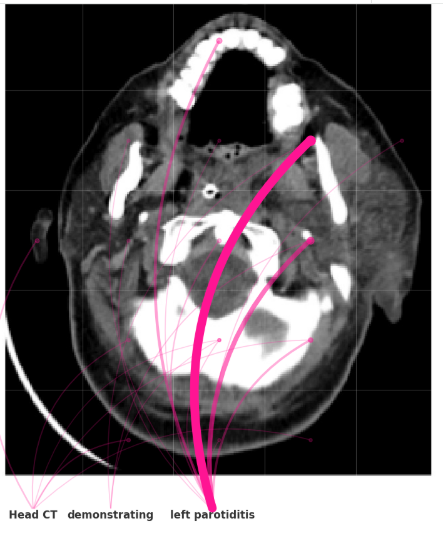

In [ ]:
metrics_data, curves_data, common_x=run_benchmark_metrics(short_samples_subset, n_samples_explainer=10000, n_images=10, mode="cross_modal", n_grid=5)

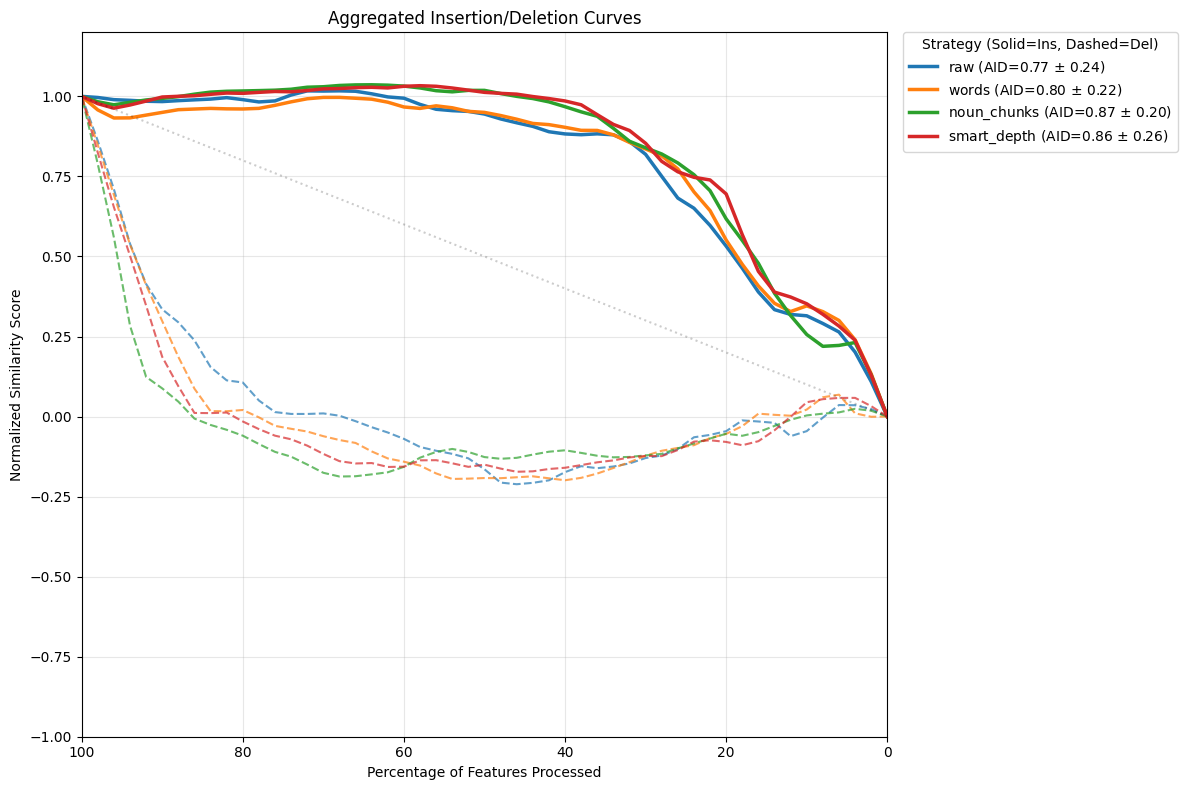

In [ ]:
plot_aggregated_curves(curves_data, common_x)

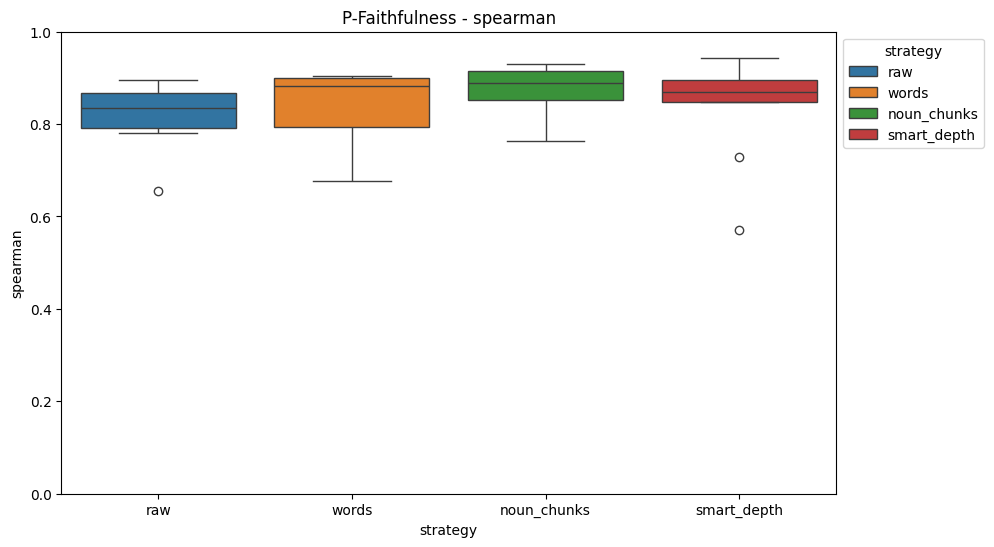

             spearman
strategy             
noun_chunks  0.875449
raw          0.816116
smart_depth  0.834957
words        0.835406


In [ ]:
plot_p_faithfulness_boxplot(metrics_data, metric_name="spearman")

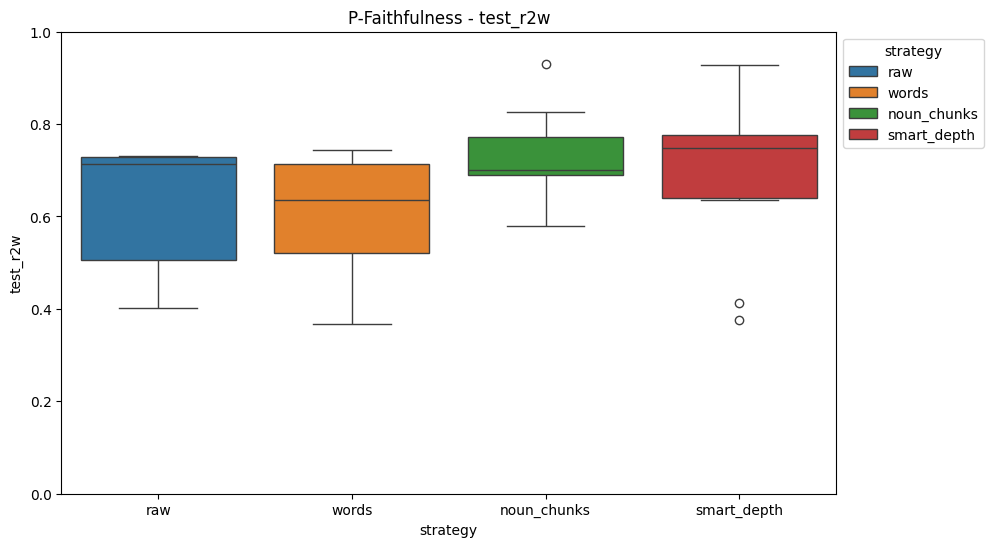

             test_r2w
strategy             
noun_chunks  0.723071
raw          0.626612
smart_depth  0.685640
words        0.603155


In [ ]:
plot_p_faithfulness_boxplot(metrics_data, metric_name="test_r2w")

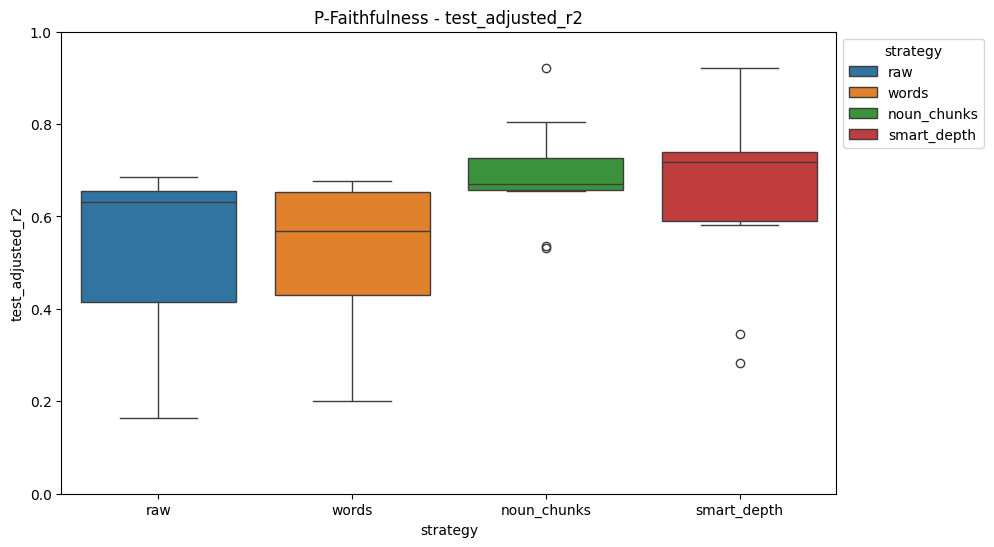

             test_adjusted_r2
strategy                     
noun_chunks          0.687490
raw                  0.526883
smart_depth          0.643909
words                0.511294


In [ ]:
plot_p_faithfulness_boxplot(metrics_data, metric_name="test_adjusted_r2")

In [ ]:
metrics_data, curves_data, common_x=run_benchmark_metrics(short_samples_subset, n_samples_explainer=10000, n_images=10, mode="cross_modal", n_grid=5, p=0.7)

In [ ]:
plot_aggregated_curves(curves_data, common_x)

In [ ]:
plot_p_faithfulness_boxplot(metrics_data, metric_name="spearman")

In [ ]:
plot_p_faithfulness_boxplot(metrics_data_filter, metric_name="test_r2w")

In [ ]:
metrics_data, curves_data, common_x=run_benchmark_metrics(short_samples_subset, n_samples_explainer=10000, n_images=3, mode="full", n_grid=5, p=0.5)

In [ ]:
plot_p_faithfulness_boxplot(metrics_data, metric_name="train_r2w")

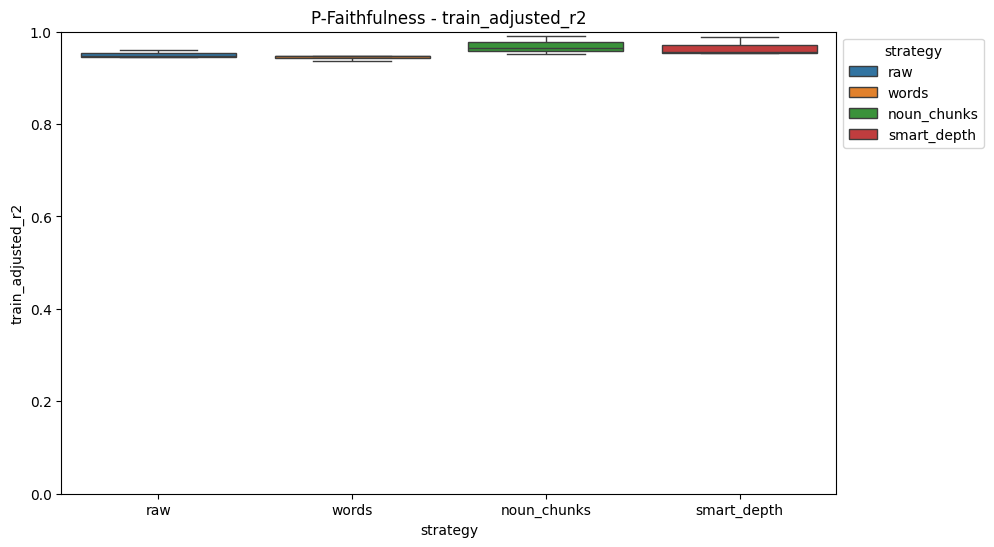

             train_adjusted_r2
strategy                      
noun_chunks           0.968285
raw                   0.950973
smart_depth           0.965572
words                 0.944027


In [ ]:
plot_p_faithfulness_boxplot(metrics_data, metric_name="train_adjusted_r2")

Chosen experiments on long subsets

In [ ]:
metrics_data2, curves_data2, common_x2=run_benchmark_metrics(long_samples_subset, n_samples_explainer=50000, n_images=5, mode="cross_modal", n_grid=4)

In [ ]:
plot_aggregated_curves(curves_data2, common_x2)

In [ ]:
plot_p_faithfulness_boxplot(metrics_data2, metric_name="test_r2w")

In [ ]:
plot_p_faithfulness_boxplot(metrics_data2, metric_name="test_adjusted_r2")

Rotations

In [ ]:
photo=dataset_roco_subset[0]

In [ ]:
img_original = photo["image"]

img_rot90 = img_original.transpose(Image.ROTATE_270)
img_mirror = img_original.transpose(Image.FLIP_LEFT_RIGHT)
img_rot180 = img_original.transpose(Image.ROTATE_180)
img_rot270 = img_original.transpose(Image.ROTATE_90)
img_mirror = img_original.transpose(Image.FLIP_LEFT_RIGHT)
five_photos_list = [img_rot270, img_mirror, img_original, img_rot90, img_rot180]

titles = ["original", "rotation 90", "rotation 180", "rotation 270", "mirror"]

plt.figure(figsize=(15, 5))
for i, (img, title) in enumerate(zip(five_photos_list, titles)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
dataset_rotations=[]
for i in range(len(five_photos_list)):
    sample = {}
    sample["image"]=five_photos_list[i]
    sample["caption"]=photo["caption"]
    dataset_rotations.append(sample)

In [ ]:
metrics_data, curves_data, common_x=run_benchmark_metrics(dataset_rotations, n_samples_explainer=10000, n_images=3, mode="cross_modal", n_grid=5)

mode full

In [ ]:
metrics_data, curves_data, common_x=run_benchmark_metrics(dataset_roco_subset, n_samples_explainer=100000, n_images=10, mode="full")

more n_samples

In [ ]:
metrics_data, curves_data, common_x=run_benchmark_metrics(dataset_roco_subset2, n_samples_explainer=1000000, n_images=1)

Both short and long captions

In [ ]:
metrics_data, curves_data, common_x=run_benchmark_metrics(dataset_roco_subset2, n_samples_explainer=100000, n_images=10, p=0.7)